In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import pandas as pd
import numpy as np
import edhec_risk_kit as erk
from scipy.stats import norm
from scipy.optimize import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
ind = erk.get_ind30_returns()
er = erk.annualized_return(ind['1996':'2000'],12)
cov = ind['1996':'2000'].cov()

In [17]:
def msr(riskfree_rate,er,cov):
    '''
    from a target return (for ex. the 0.15) to the weight vector , r -> w
    '''
    n = er.shape[0]
    init_guess = np.repeat(1/n,n)
    bounds = ((0.0,1.0),) * n
    weights_sum_to1 = {
        'type':'eq',
        'fun':lambda weights : np.sum(weights)-1
    }
    def negative_sharpe_ratio(weights, riskfree_rate, er, cov):
        'the negative sharpe, !!! given weights'
        r = erk.portfolio_return(weights, er)
        vol = erk.portfolio_vol(weights, cov)
        return -(r-riskfree_rate)/vol
    
    'we want to maximize the sharpe , so we minimize -sharpe'
    results = minimize(negative_sharpe_ratio,init_guess,
                       args=(riskfree_rate,er,cov,),method='SLSQP',
                       options={'disp':False},
                       constraints=(weights_sum_to1),
                       bounds=bounds
                      )
    return results.x

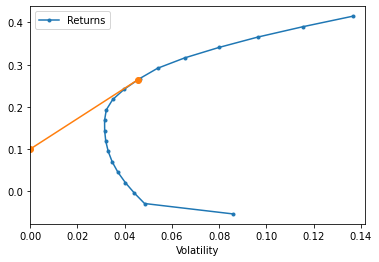

In [18]:
ax = erk.plot_ef(20,er,cov)
ax.set_xlim(left=0)
rf = 0.1
w_msr = msr(rf,er,cov)
r_msr = erk.portfolio_return(w_msr,er)
vol_msr = erk.portfolio_vol(w_msr,cov)
#we plot the cml
cml_x=[0,vol_msr]
cml_y=[rf,r_msr]
ax.plot(cml_x,cml_y,marker='o')

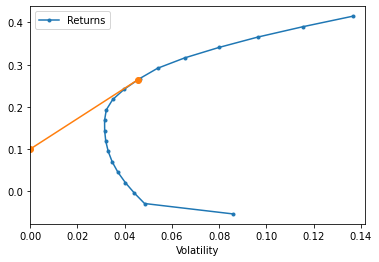

In [22]:
ax = erk.plot_ef(20,er,cov,riskfree_rate=0.1,show_cml=True)

In [ ]:
ax = erk.plot_ef(20,er,cov,show_cml=True)